# Sprint 7: Analisis de Componentes Principales (ACP) y Clustering de IES (Issue 7.2)

Este notebook realiza el agrupamiento de las Instituciones de Educacion Superior (IES)
en Colombia segun su desempeno academico en las pruebas Saber Pro y sus metricas SNIES
(matricula, graduacion y acreditacion).

### Pipeline:
1. **Carga memory-safe** de Saber Pro (~2.7M registros, solo columnas necesarias)
2. **Integracion SNIES** respetando la regla MEN de semestres para matricula anual
3. **Feature engineering** por IES (9 variables)
4. **ACP / PCA** para reducir dimensiones (reteniendo >= 70% varianza)
5. **K-Means** sobre las componentes principales reducidas (NO sobre variables originales)
6. **Biplot** de IES en espacio PC1 vs PC2 con vectores de carga
7. **Perfiles de cluster** y auditoria

### Regla MEN para Matricula Anual SNIES:
- **Primer semestre**: se cuenta como matricula anual para TODAS las IES excepto el SENA
- **Segundo semestre**: se cuenta SOLO para el SENA (quienes inician ahi)
- Esto evita duplicaciones y refleja la metodologia oficial del Ministerio de Educacion Nacional


In [9]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path
import json
import pickle
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Configuracion de visualizacion
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Rutas
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATOS_DIR = PROJECT_ROOT / 'datos' / 'processed'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'

# Crear subdirectorios de artifacts si no existen
for subdir in ['modelos', 'metricas', 'visualizaciones']:
    (ARTIFACTS_DIR / subdir).mkdir(parents=True, exist_ok=True)

print("Setup completo!")
print(f"Ruta del proyecto: {PROJECT_ROOT}")

Setup completo!
Ruta del proyecto: c:\Users\German\Pictures\Proyecto-Observatorio-Datos-de-Educacion-en-Colombia


## 1. Carga de Datos (Memory-Safe)
Cargamos unicamente las columnas necesarias del dataset unificado de Saber Pro
(que contiene mas de 2.6M de registros y 150+ columnas originalmente).
Tambien cargamos los datos de SNIES graduados (para el puente de codigos) y el
dataset consolidado que ya aplica la regla MEN de semestres.

In [10]:
# Cargar Saber Pro (filtrado por columnas para optimizar la RAM)
print("Cargando Saber Pro...")
df_saberpro = pd.read_parquet(
    DATOS_DIR / 'saber_pro' / 'saber_pro_consolidado.parquet',
    columns=['nombre_ies', 'puntaje_global', 'punt_razona_cuantitativa',
             'punt_lectura_critica', 'punt_ingles', 'estu_consecutivo', 'codigo_snies_programa']
)
print(f"Saber Pro cargado: {len(df_saberpro):,} registros, {df_saberpro.memory_usage(deep=True).sum()/1e6:.1f} MB")

Cargando Saber Pro...
Saber Pro cargado: 2,683,632 registros, 312.7 MB


## 2. Integracion y Creacion de Features Agregadas por IES (Saber Pro + SNIES)

Calculamos 9 features por cada IES cruzando Saber Pro con SNIES:

| # | Feature | Fuente |
|---|---------|--------|
| 1 | `puntaje_global` (promedio) | Saber Pro |
| 2 | `punt_razona_cuantitativa` (promedio) | Saber Pro |
| 3 | `punt_lectura_critica` (promedio) | Saber Pro |
| 4 | `punt_ingles` (promedio) | Saber Pro |
| 5 | `n_presentaciones` (conteo) | Saber Pro |
| 6 | `prop_p75_plus` (proporcion en percentil 75+) | Saber Pro |
| 7 | `total_matriculados` (promedio anual, regla MEN) | SNIES |
| 8 | `total_graduados` (promedio anual) | SNIES |
| 9 | `es_acreditada` (binario) | SNIES |

**Puente Saber Pro <-> SNIES:** usamos `codigo_snies_programa` como llave comun.

**Regla MEN:** `dataset_snies_consolidado.parquet` ya aplica Sem1 todas IES + Sem2 solo SENA.

In [11]:
print("Creando features de Saber Pro por IES...")

# Puntajes promedio por IES
features_ies = df_saberpro.groupby('nombre_ies').agg({
    'puntaje_global': 'mean',
    'punt_razona_cuantitativa': 'mean',
    'punt_lectura_critica': 'mean',
    'punt_ingles': 'mean',
    'estu_consecutivo': 'count'
}).rename(columns={'estu_consecutivo': 'n_presentaciones'})

# Calcular proporcion en P75+ (optimizado para memoria)
print("Calculando proporcion P75+...")
p75_global = df_saberpro['puntaje_global'].quantile(0.75)

df_temp = df_saberpro[['nombre_ies', 'puntaje_global']].copy()
df_temp['es_p75_plus'] = (df_temp['puntaje_global'] >= p75_global).astype(int)
prop_p75 = df_temp.groupby('nombre_ies')['es_p75_plus'].mean().rename('prop_p75_plus')
del df_temp  # Liberar memoria

features_ies = features_ies.join(prop_p75)

print("Cruzando con datos del SNIES usando codigo SNIES de programa...")

# 1. Cargar SNIES Graduados crudo para mapear codigo de programa a codigo de IES
df_grad_raw = pd.read_parquet(
    DATOS_DIR / 'snies' / 'snies_graduados_limpio_consolidado.parquet',
    columns=['codigo_snies_programa', 'codigo_institucion', 'ies_acreditada']
)
df_grad_raw['codigo_snies_programa'] = pd.to_numeric(df_grad_raw['codigo_snies_programa'], errors='coerce')
df_grad_raw = df_grad_raw.dropna(subset=['codigo_snies_programa'])

# Relacion unica programa-IES
prog_to_ies = df_grad_raw[['codigo_snies_programa', 'codigo_institucion']].drop_duplicates().dropna()

# 2. Relacion programa-IES en Saber Pro
sp_prog = df_saberpro[['nombre_ies', 'codigo_snies_programa']].drop_duplicates().dropna()
sp_prog['codigo_snies_programa'] = pd.to_numeric(sp_prog['codigo_snies_programa'], errors='coerce')
sp_prog = sp_prog.dropna()

# 3. Cruzar para obtener el mapeo nombre_ies -> codigo_institucion (SNIES)
merged_bridge = pd.merge(sp_prog, prog_to_ies, on='codigo_snies_programa', how='inner')
ies_mapping = merged_bridge.groupby('nombre_ies')['codigo_institucion'].agg(lambda x: x.value_counts().index[0]).reset_index()

# 4. Cargar dataset consolidado de SNIES (YA implementa regla MEN: Sem1 todas + Sem2 solo SENA)
df_snies = pd.read_parquet(DATOS_DIR / 'snies' / 'dataset_snies_consolidado.parquet')

# Promedio anual de graduados y matriculados de SNIES
snies_agg = df_snies.groupby('codigo_institucion').agg({
    'total_matriculados': 'mean',
    'total_graduados': 'mean'
}).reset_index()

# 5. Obtener acreditacion (SI / NO) por IES
df_grad_raw['es_acreditada'] = df_grad_raw['ies_acreditada'].apply(lambda x: 1 if str(x).strip().upper() in ['SI', 'S', '1'] else 0)
ies_acred = df_grad_raw.groupby('codigo_institucion')['es_acreditada'].max().reset_index()

# Unificar agregaciones de SNIES
snies_agg = pd.merge(snies_agg, ies_acred, on='codigo_institucion', how='left')

# Cruzar SNIES con el mapping de nombres
snies_mapped = pd.merge(ies_mapping, snies_agg, on='codigo_institucion', how='inner')

# 6. Unificar features en features_ies
features_ies = pd.merge(features_ies, snies_mapped[['nombre_ies', 'total_matriculados', 'total_graduados', 'es_acreditada']],
                        on='nombre_ies', how='left')

# Filtrar IES con al menos 100 presentaciones para evitar ruido
features_ies = features_ies[features_ies['n_presentaciones'] >= 100].copy()

# Imputar valores nulos de SNIES con la mediana
features_ies['total_matriculados'] = features_ies['total_matriculados'].fillna(features_ies['total_matriculados'].median())
features_ies['total_graduados'] = features_ies['total_graduados'].fillna(features_ies['total_graduados'].median())
features_ies['es_acreditada'] = features_ies['es_acreditada'].fillna(0).astype(int)

# Establecer nombre_ies como indice
features_ies = features_ies.set_index('nombre_ies')

print(f"\nFeatures integradas creadas para {len(features_ies)} IES con >= 100 presentaciones.")
print(f"Variables: {features_ies.columns.tolist()}")
display(features_ies.head(10))

Creando features de Saber Pro por IES...
Calculando proporcion P75+...
Cruzando con datos del SNIES usando codigo SNIES de programa...

Features integradas creadas para 336 IES con >= 100 presentaciones.
Variables: ['puntaje_global', 'punt_razona_cuantitativa', 'punt_lectura_critica', 'punt_ingles', 'n_presentaciones', 'prop_p75_plus', 'total_matriculados', 'total_graduados', 'es_acreditada']


,puntaje_global,punt_razona_cuantitativa,punt_lectura_critica,punt_ingles,n_presentaciones,prop_p75_plus,total_matriculados,total_graduados,es_acreditada
nombre_ies,,,,,,,,,
CENTRO DE EDUCACION MILITAR-BOGOTÃ D.C.,125.365697,135.023394,125.753211,137.469037,218,0.366972,639.800000,747.700000,0
COLEGIO DE ESTUDIOS SUPERIORES DE ADMINISTRACION-CESA-BOGOTÃ D.C.,167.599080,165.724499,161.830191,194.125583,2196,0.838798,1752.000000,507.500000,1
COLEGIO MAYOR DE ANTIOQUIA-MEDELLIN,134.239433,136.093550,138.840590,136.617670,4713,0.254615,4702.900000,746.700000,1
COLEGIO MAYOR DE BOLIVAR-CARTAGENA,68.701544,64.827121,68.618915,75.748192,719,0.034771,2287.800000,641.800000,0
COLEGIO MAYOR DE NUESTRA SEÃORA DEL ROSARIO-BOGOTÃ D.C.,163.442073,154.166587,164.401029,183.149454,15943,0.747538,11760.818182,3426.454545,1
COLEGIO MAYOR DEL CAUCA-POPAYAN,120.756553,122.428387,121.660000,123.670676,2945,0.096435,2221.100000,532.200000,0
CONSERVATORIO DEL TOLIMA-IBAGUE,127.802783,124.304717,135.276887,137.891274,424,0.231132,382.200000,52.100000,1
CORPORACION ACADEMIA SUPERIOR DE ARTES-MEDELLIN,10.165111,9.863889,10.314815,10.463426,108,0.000000,256.500000,49.400000,0
CORPORACION COLEGIATURA COLOMBIANA-MEDELLIN,136.990625,128.300799,137.410392,168.258833,1251,0.354916,776.100000,162.100000,0


## 3. Analisis de Correlacion de Variables
Analizamos como se correlacionan las 9 features a nivel de IES.
Esto nos da una primera intuicion de por que el PCA podra reducir dimensiones:
variables altamente correlacionadas seran capturadas por una misma componente principal.

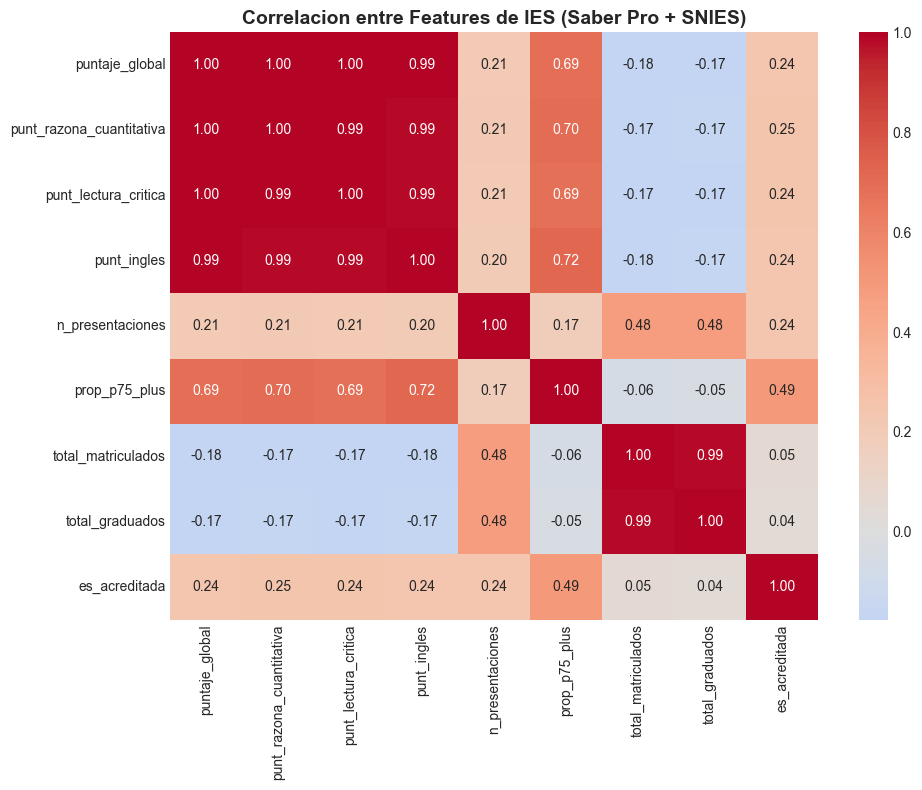

In [12]:
# Correlacion entre features
plt.figure(figsize=(10, 8))
sns.heatmap(features_ies.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlacion entre Features de IES (Saber Pro + SNIES)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Normalizacion y Analisis de Componentes Principales (ACP / PCA)

**Paso critico:** Dado que las variables tienen diferentes escalas (puntajes ~150,
matriculados ~10,000, binario 0/1), las normalizamos a media=0 y desviacion estandar=1.

Luego aplicamos PCA para:
1. **Analizar** cuantas componentes explican >= 70% de la varianza total
2. **REDUCIR** las dimensiones de entrada al clustering a ese numero de componentes

> **IMPORTANTE:** El clustering K-Means se entrena sobre las **componentes principales
> reducidas**, NO sobre las 9 variables originales. Esto elimina multicolinealidad
> y ruido de variables redundantes.

In [13]:
# Normalizar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_ies)

# PCA COMPLETO para analizar la varianza de TODAS las componentes
pca_full = PCA()
pca_full.fit(X_scaled)

varianza_explicada = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

print("Varianza explicada por cada Componente Principal:")
for i, var in enumerate(varianza_explicada):
    marker = " <-- " if varianza_acumulada[i] >= 0.70 and (i == 0 or varianza_acumulada[i-1] < 0.70) else ""
    print(f"  PC{i+1}: {var*100:.2f}% (Acumulada: {varianza_acumulada[i]*100:.2f}%){marker}")

# Determinar numero optimo de componentes (>= 70% varianza)
N_COMPONENTS = int(np.argmax(varianza_acumulada >= 0.70) + 1)
print(f"\n>>> Componentes necesarias para >= 70% varianza: {N_COMPONENTS}")
print(f">>> Reduccion de dimensiones: {X_scaled.shape[1]} variables -> {N_COMPONENTS} componentes principales")

Varianza explicada por cada Componente Principal:
  PC1: 52.85% (Acumulada: 52.85%)
  PC2: 26.22% (Acumulada: 79.07%) <-- 
  PC3: 10.94% (Acumulada: 90.01%)
  PC4: 6.36% (Acumulada: 96.38%)
  PC5: 3.29% (Acumulada: 99.67%)
  PC6: 0.14% (Acumulada: 99.81%)
  PC7: 0.11% (Acumulada: 99.93%)
  PC8: 0.07% (Acumulada: 100.00%)
  PC9: 0.00% (Acumulada: 100.00%)

>>> Componentes necesarias para >= 70% varianza: 2
>>> Reduccion de dimensiones: 9 variables -> 2 componentes principales


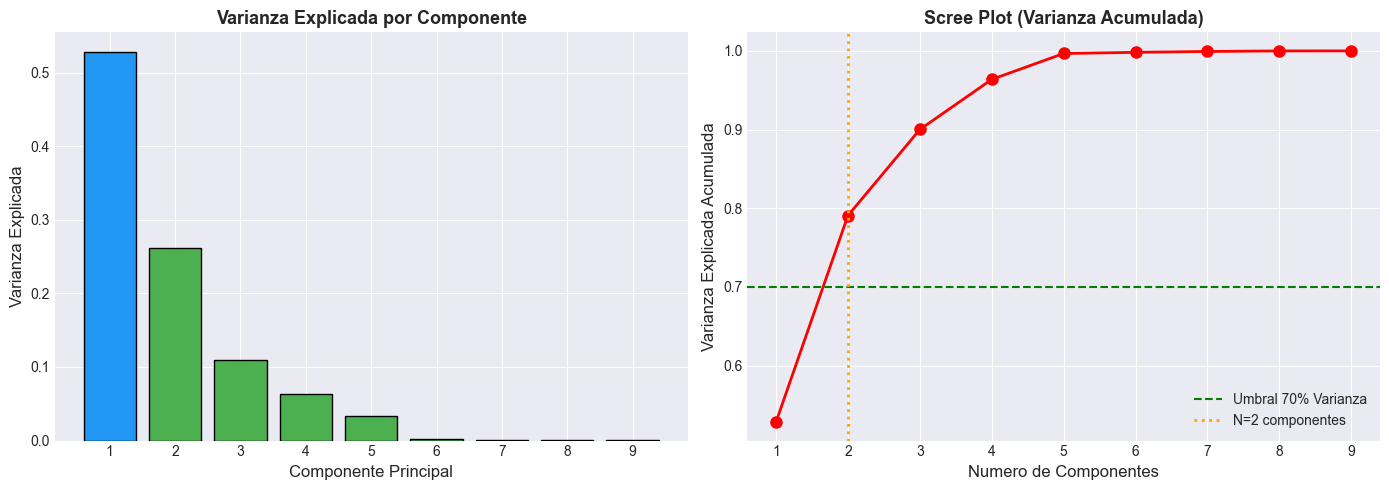

In [14]:
# Visualizar varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot de varianza por componente
colors = ['#2196F3' if varianza_acumulada[i] < 0.70 else '#4CAF50' for i in range(len(varianza_explicada))]
axes[0].bar(range(1, len(varianza_explicada)+1), varianza_explicada, color=colors, edgecolor='black')
axes[0].set_xlabel('Componente Principal', fontsize=12)
axes[0].set_ylabel('Varianza Explicada', fontsize=12)
axes[0].set_title('Varianza Explicada por Componente', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(1, len(varianza_explicada)+1))

# Lineplot de varianza acumulada
axes[1].plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Numero de Componentes', fontsize=12)
axes[1].set_ylabel('Varianza Explicada Acumulada', fontsize=12)
axes[1].set_title('Scree Plot (Varianza Acumulada)', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(1, len(varianza_acumulada)+1))
axes[1].axhline(y=0.7, color='g', linestyle='--', label='Umbral 70% Varianza')
axes[1].axvline(x=N_COMPONENTS, color='orange', linestyle=':', lw=2, label=f'N={N_COMPONENTS} componentes')
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
# =====================================================================
# REDUCCION DE DIMENSIONES: Proyectar datos a N_COMPONENTS principales
# =====================================================================
# Este es el paso critico: K-Means se entrenara sobre X_pca_reduced,
# NO sobre X_scaled (que tiene 9 dimensiones con multicolinealidad)

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca_reduced = pca.fit_transform(X_scaled)

print(f"Matriz de entrada al clustering:")
print(f"  Antes (X_scaled):       {X_scaled.shape[0]} IES x {X_scaled.shape[1]} variables")
print(f"  Despues (X_pca_reduced): {X_pca_reduced.shape[0]} IES x {X_pca_reduced.shape[1]} componentes")
print(f"  Varianza retenida: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Mostrar tabla de loadings (contribucion de cada variable a cada PC)
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=features_ies.columns,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)
print(f"\nLoadings (contribucion de cada variable a cada componente):")
display(loadings_df.style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1).format('{:.3f}'))

Matriz de entrada al clustering:
  Antes (X_scaled):       336 IES x 9 variables
  Despues (X_pca_reduced): 336 IES x 2 componentes
  Varianza retenida: 79.1%

Loadings (contribucion de cada variable a cada componente):


,PC1,PC2
puntaje_global,0.450,0.006
punt_razona_cuantitativa,0.450,0.009
punt_lectura_critica,0.449,0.007
punt_ingles,0.451,0.006
n_presentaciones,0.101,0.474
prop_p75_plus,0.364,0.088
total_matriculados,-0.099,0.609
total_graduados,-0.097,0.608
es_acreditada,0.168,0.164


## 5. Seleccion del Numero Optimo de Clusters (K)
Probamos K de 2 a 10 usando **las componentes principales reducidas** (no las variables
originales). Evaluamos con Inercia (WCSS), Silhouette Score y Davies-Bouldin Index.

In [16]:
# Probar diferentes valores de K sobre X_pca_reduced
K_range = range(2, 11)
inertias = []
silhouette_scores = []
davies_bouldin_scores = []

print("Calculando metricas para K = 2 a 10 (sobre componentes PCA reducidas)...")

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca_reduced)  # <-- SOBRE PCA REDUCIDO

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca_reduced, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_pca_reduced, labels))

# Tabla resumen
df_metrics = pd.DataFrame({
    'K': list(K_range),
    'Inercia': inertias,
    'Silhouette': silhouette_scores,
    'Davies-Bouldin': davies_bouldin_scores
}).set_index('K')

print("\nResumen de metricas por K:")
display(df_metrics.style.highlight_max(subset=['Silhouette'], color='lightgreen')
                        .highlight_min(subset=['Davies-Bouldin'], color='lightyellow')
                        .format('{:.3f}'))

Calculando metricas para K = 2 a 10 (sobre componentes PCA reducidas)...

Resumen de metricas por K:


,Inercia,Silhouette,Davies-Bouldin
K,,,
2,1139.383,0.675,0.554
3,594.123,0.675,0.367
4,373.046,0.494,0.577
5,295.665,0.497,0.570
6,228.831,0.477,0.612
7,176.191,0.463,0.633
8,146.111,0.433,0.655
9,124.721,0.457,0.637
10,105.457,0.462,0.601


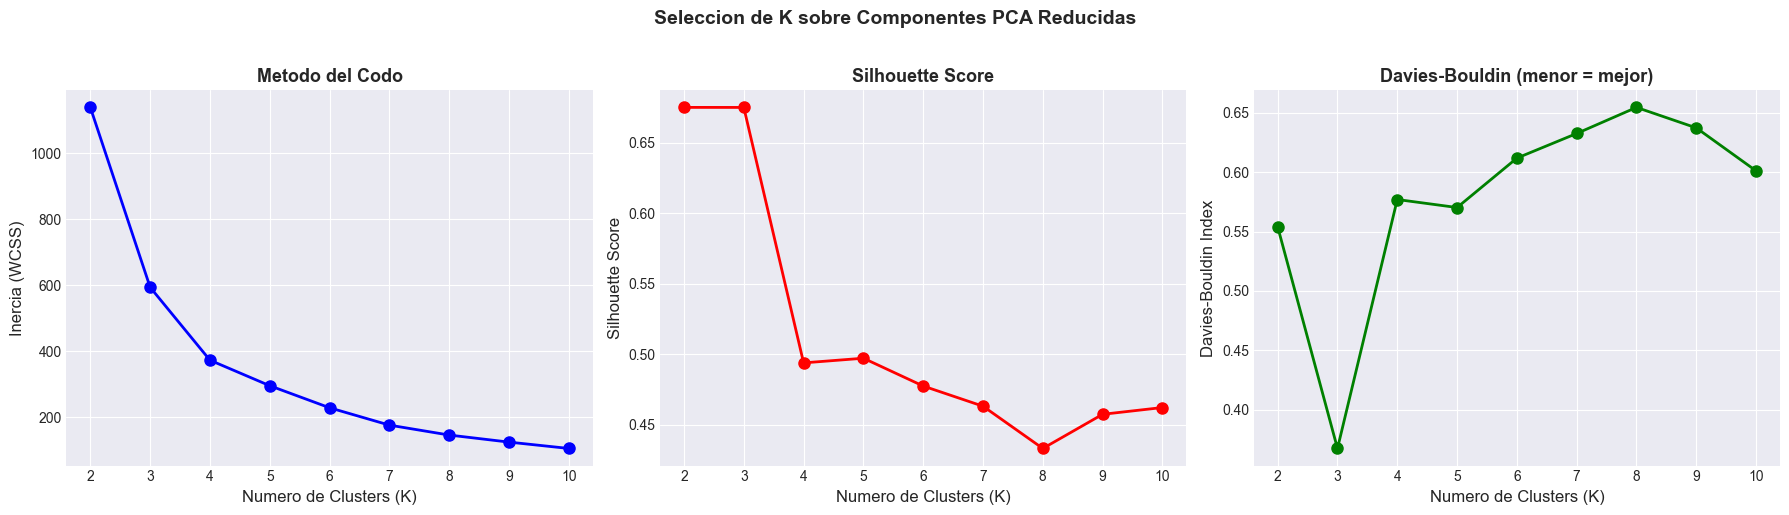

In [17]:
# Visualizar metodo del codo y silhouette
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Metodo del codo
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Numero de Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inercia (WCSS)', fontsize=12)
axes[0].set_title('Metodo del Codo', fontsize=13, fontweight='bold')
axes[0].set_xticks(K_range)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Numero de Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
axes[1].set_xticks(K_range)

# Davies-Bouldin Index
axes[2].plot(K_range, davies_bouldin_scores, 'go-', linewidth=2, markersize=8)
axes[2].set_xlabel('Numero de Clusters (K)', fontsize=12)
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[2].set_title('Davies-Bouldin (menor = mejor)', fontsize=13, fontweight='bold')
axes[2].set_xticks(K_range)

plt.suptitle('Seleccion de K sobre Componentes PCA Reducidas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Entrenamiento del Modelo Final (K-Means sobre PCA Reducido)
Entrenamos el modelo con el K optimo (seleccionado por Silhouette Score maximo)
sobre las **componentes principales reducidas**.

In [18]:
# Seleccionar K optimo basado en Silhouette Score maximo
K_OPTIMO = list(K_range)[np.argmax(silhouette_scores)]
print(f"K optimo seleccionado: {K_OPTIMO} (Silhouette: {max(silhouette_scores):.3f})")

# Entrenar K-Means SOBRE PCA REDUCIDO
kmeans_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=20)
labels_final = kmeans_final.fit_predict(X_pca_reduced)  # <-- SOBRE PCA REDUCIDO

# Agregar la etiqueta del cluster al dataframe original
features_ies['cluster'] = labels_final

# Metricas de calidad
silh_final = silhouette_score(X_pca_reduced, labels_final)
db_final = davies_bouldin_score(X_pca_reduced, labels_final)
ch_final = calinski_harabasz_score(X_pca_reduced, labels_final)

print(f"\nMetricas del modelo de K={K_OPTIMO} clusters (sobre {N_COMPONENTS} componentes PCA):")
print(f"  Silhouette Score:        {silh_final:.3f}")
print(f"  Davies-Bouldin Index:    {db_final:.3f}")
print(f"  Calinski-Harabasz Score: {ch_final:.1f}")

print(f"\nDistribucion de IES por cluster:")
print(features_ies['cluster'].value_counts().sort_index())

K optimo seleccionado: 2 (Silhouette: 0.675)

Metricas del modelo de K=2 clusters (sobre 2 componentes PCA):
  Silhouette Score:        0.675
  Davies-Bouldin Index:    0.554
  Calinski-Harabasz Score: 367.0

Distribucion de IES por cluster:
cluster
0    267
1     69
Name: count, dtype: int64


## 7. Visualizacion del Espacio PCA y Biplot
Graficamos la proyeccion de las IES en el plano PC1 vs PC2 y superponemos los
vectores de carga de cada variable original (Biplot) para entender que variables
determinan la formacion de los clusters.

> Las IES estan coloreadas por su cluster asignado (entrenado sobre las dimensiones
> PCA reducidas, no sobre las variables originales).

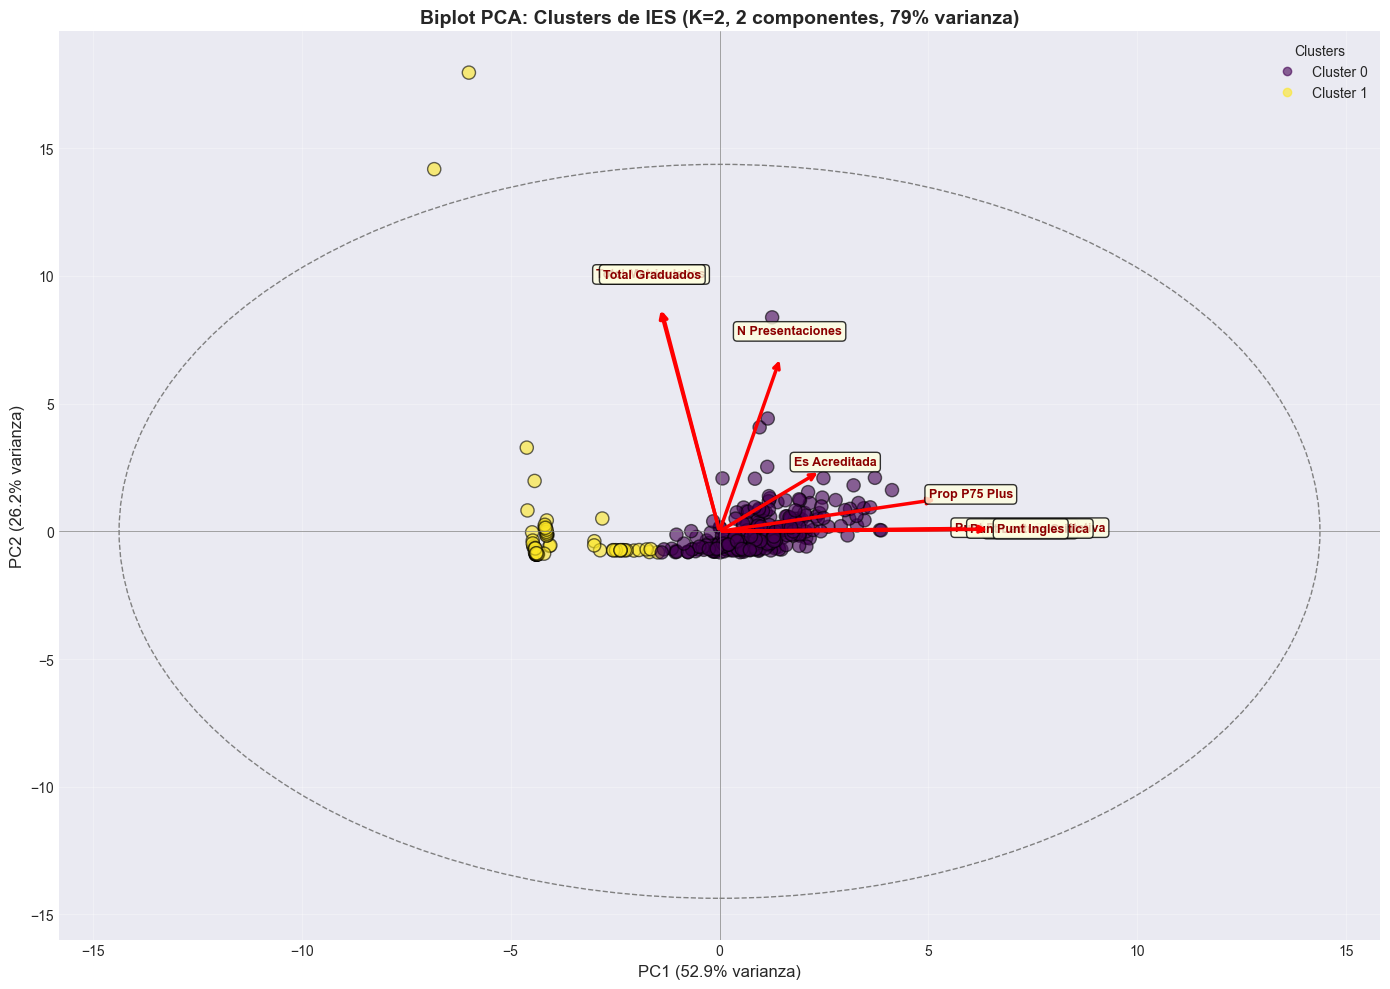

In [19]:
# === BIPLOT PCA y Clusters de IES ===
# Siempre usamos las 2 primeras componentes para la visualizacion
X_pca_2d = X_pca_reduced[:, :2] if X_pca_reduced.shape[1] >= 2 else pca.transform(X_scaled)[:, :2]

fig, ax = plt.subplots(figsize=(14, 10))

# Scatter de IES en espacio PCA coloreado por Cluster
scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_final,
                     cmap='viridis', alpha=0.6, s=90, edgecolors='k')

# Obtener loadings (direccion y magnitud de variables originales en PCA)
loadings = pca.components_.T
feature_names_pca = features_ies.drop(columns=['cluster'], errors='ignore').columns.tolist()

# Escalar flechas
scale = np.abs(X_pca_2d).max() * 0.8

for j, fname in enumerate(feature_names_pca):
    ax.annotate('',
        xy=(loadings[j, 0] * scale, loadings[j, 1] * scale),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='red', lw=2.5)
    )
    # Etiqueta de la variable
    ax.text(loadings[j, 0] * scale * 1.15,
            loadings[j, 1] * scale * 1.15,
            fname.replace('_', ' ').title(),
            fontsize=9, fontweight='bold', color='darkred',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# Circulo unitario de referencia
circle = plt.Circle((0, 0), scale, fill=False, color='gray', linestyle='--', lw=1)
ax.add_patch(circle)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
ax.set_title(f'Biplot PCA: Clusters de IES (K={K_OPTIMO}, {N_COMPONENTS} componentes, {pca.explained_variance_ratio_.sum()*100:.0f}% varianza)',
             fontsize=14, fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='-', lw=0.5)
ax.axvline(x=0, color='gray', linestyle='-', lw=0.5)
ax.grid(True, alpha=0.3)

# Leyenda
handles, _ = scatter.legend_elements()
legend_labels = [f'Cluster {i}' for i in range(len(handles))]
ax.legend(handles, legend_labels, title='Clusters', loc='best')

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'visualizaciones' / f'clusters_ies_pca_biplot_{datetime.now().strftime("%Y%m%d")}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 8. Analisis de Perfiles por Cluster
Calculamos los promedios y desviaciones estandar de cada variable ORIGINAL en cada cluster.
Esto nos permite interpretar que caracteriza a cada grupo de IES.

In [20]:
# Calcular perfiles
perfiles = features_ies.groupby('cluster').agg({
    'puntaje_global': ['mean', 'std', 'count'],
    'punt_razona_cuantitativa': 'mean',
    'punt_lectura_critica': 'mean',
    'punt_ingles': 'mean',
    'prop_p75_plus': 'mean',
    'n_presentaciones': ['sum', 'mean'],
    'total_matriculados': ['sum', 'mean'],
    'total_graduados': ['sum', 'mean'],
    'es_acreditada': 'mean'
})

perfiles.columns = ['_'.join(col).strip() for col in perfiles.columns.values]
perfiles = perfiles.round(2)

print("\nResumen de Perfiles por Cluster:")
display(perfiles)

# Guardar perfiles
perfiles.to_csv(ARTIFACTS_DIR / 'metricas' / f'perfiles_clusters_{datetime.now().strftime("%Y%m%d")}.csv')


Resumen de Perfiles por Cluster:


,puntaje_global_mean,puntaje_global_std,puntaje_global_count,punt_razona_cuantitativa_mean,punt_lectura_critica_mean,punt_ingles_mean,prop_p75_plus_mean,n_presentaciones_sum,n_presentaciones_mean,total_matriculados_sum,total_matriculados_mean,total_graduados_sum,total_graduados_mean,es_acreditada_mean
cluster,,,,,,,,,,,,,,
0,130.33,14.73,267,129.77,132.99,136.45,0.25,2472798,9261.42,1959044.62,7337.25,388934.44,1456.68,0.48
1,25.08,24.70,69,24.51,25.16,25.32,0.01,176066,2551.68,1513074.45,21928.62,286936.59,4158.50,0.29


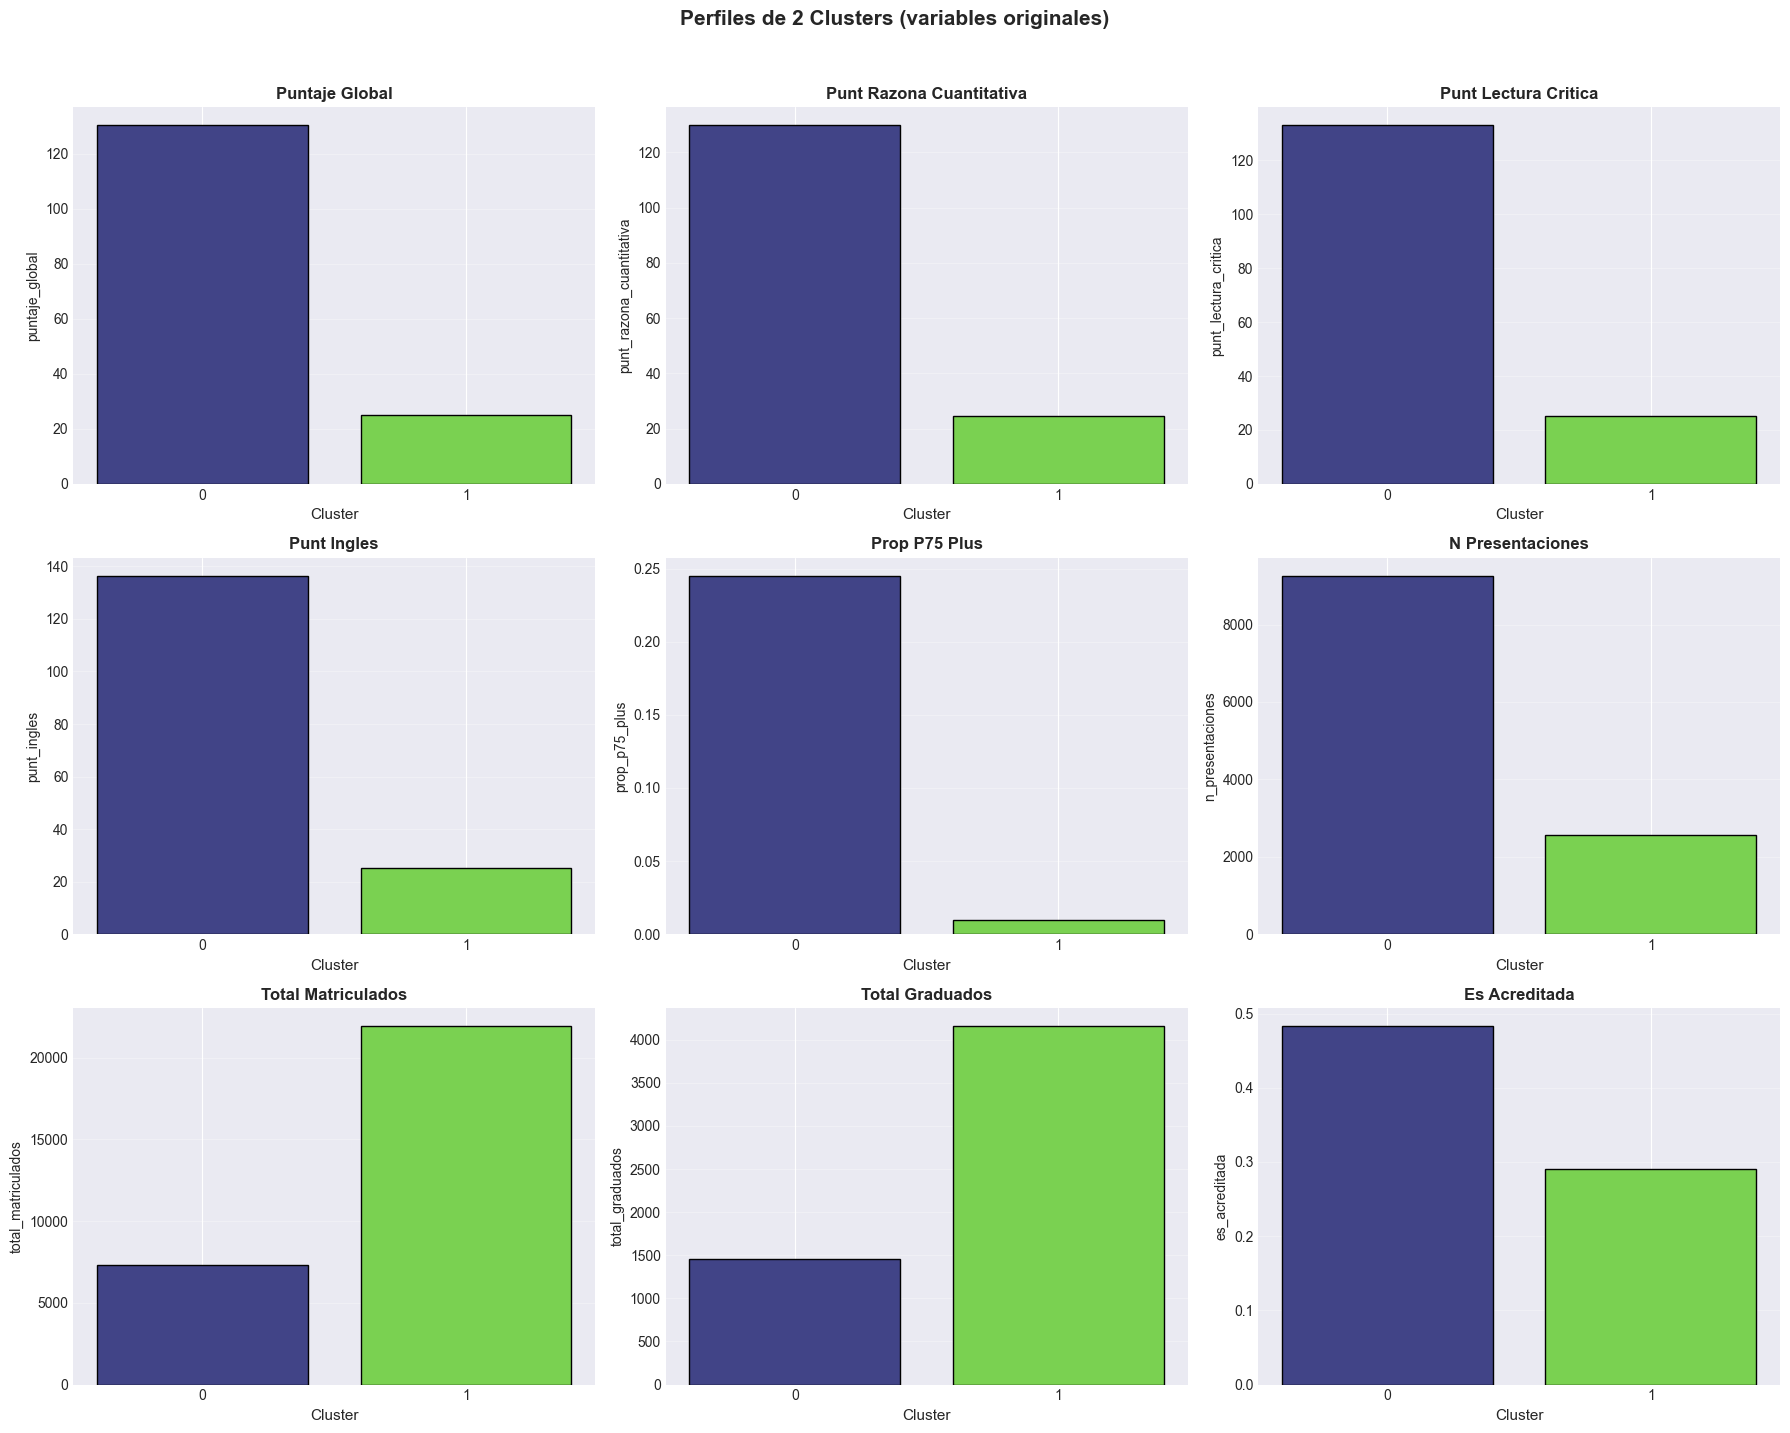

In [21]:
# Visualizar perfiles por cluster
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

features_to_plot = ['puntaje_global', 'punt_razona_cuantitativa',
                    'punt_lectura_critica', 'punt_ingles',
                    'prop_p75_plus', 'n_presentaciones',
                    'total_matriculados', 'total_graduados', 'es_acreditada']

# Colores por cluster
cluster_colors = plt.cm.viridis(np.linspace(0.2, 0.8, K_OPTIMO))

for idx, feat in enumerate(features_to_plot):
    cluster_means = features_ies.groupby('cluster')[feat].mean()
    bars = axes[idx].bar(cluster_means.index, cluster_means.values,
                         color=cluster_colors, edgecolor='black')
    axes[idx].set_xlabel('Cluster', fontsize=11)
    axes[idx].set_ylabel(feat, fontsize=10)
    axes[idx].set_title(f'{feat.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].set_xticks(range(K_OPTIMO))

plt.suptitle(f'Perfiles de {K_OPTIMO} Clusters (variables originales)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'visualizaciones' / 'perfiles_clusters_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Auditoria del Cluster de Desempeno Critico
Investigamos si los valores bajos del cluster de desempeno critico representan
anomalias de datos o el comportamiento real de ciertas instituciones.

In [22]:
# Identificar el cluster con peor puntaje promedio
cluster_worst = features_ies.groupby('cluster')['puntaje_global'].mean().idxmin()
cluster_worst_df = features_ies[features_ies['cluster'] == cluster_worst].copy()

print('='*70)
print(f'AUDITORIA DETALLADA: CLUSTER {cluster_worst} (DESEMPENO CRITICO)')
print('='*70)
print(f'Total de IES en Cluster {cluster_worst}: {len(cluster_worst_df)}')
print(f'Estadisticas del puntaje global en el Cluster {cluster_worst}:')
print(cluster_worst_df['puntaje_global'].describe())

print(f'\n--- IES con puntaje MAS BAJO (Top 10) ---')
display(cluster_worst_df.nsmallest(10, 'puntaje_global')[
    ['puntaje_global', 'punt_lectura_critica', 'punt_ingles', 'n_presentaciones', 'total_matriculados', 'es_acreditada']])

print(f'\n--- IES con puntaje MAS ALTO del Cluster {cluster_worst} (Top 5) ---')
display(cluster_worst_df.nlargest(5, 'puntaje_global')[
    ['puntaje_global', 'punt_lectura_critica', 'punt_ingles', 'n_presentaciones', 'total_matriculados', 'es_acreditada']])

AUDITORIA DETALLADA: CLUSTER 1 (DESEMPENO CRITICO)
Total de IES en Cluster 1: 69
Estadisticas del puntaje global en el Cluster 1:
count    69.000000
mean     25.076196
std      24.704018
min       9.321961
25%       9.794354
50%      10.026282
75%      42.337917
max      79.725000
Name: puntaje_global, dtype: float64

--- IES con puntaje MAS BAJO (Top 10) ---


,puntaje_global,punt_lectura_critica,punt_ingles,n_presentaciones,total_matriculados,es_acreditada
nombre_ies,,,,,,
UNIVERSIDAD DE LA GUAJIRA,9.321961,9.528682,9.445039,129,14394.400000,1
ESCUELA MILITAR DE SUBOFICIALES SARGENTO INOCENCIO CHINCA-NILO,9.327950,9.232158,9.540426,1219,4477.636364,0
UNIVERSIDAD DEL MAGDALENA,9.354424,9.622469,9.368938,810,22132.500000,1
CORPORACION UNIVERSITARIA DEL CARIBE,9.475605,9.667516,9.566560,157,9793.000000,0
UNIVERSIDAD DE CORDOBA,9.506694,9.766204,9.586065,216,15704.000000,1
ESCUELA DE FORMACION DE INFANTERIA DE MARINA,9.516848,9.472121,9.558667,165,282.800000,1
UNIVERSIDAD DE CARTAGENA,9.580018,9.810494,9.571102,1315,20194.000000,1
UNIVERSIDAD DE PAMPLONA,9.597095,9.798510,9.569190,1074,23834.400000,1
CORPORACION UNIVERSITARIA REGIONAL DEL CARIBE -IAFIC-,9.598745,9.647205,9.406832,161,228.285714,0



--- IES con puntaje MAS ALTO del Cluster 1 (Top 5) ---


,puntaje_global,punt_lectura_critica,punt_ingles,n_presentaciones,total_matriculados,es_acreditada
nombre_ies,,,,,,
ESCUELA DE COMUNICACIONES-FACATATIVA,79.725000,76.643210,84.788518,162,254.500000,0
IE ESCUELA NORMAL SUPERIOR DE BUCARAMANGA SEDE C-BUCARAMANGA,78.205416,77.334122,78.614358,296,3878.077273,0
ESCUELA NORMAL SUPERIOR LACIDES IRIARTE-SAHAGUN,77.091549,76.212676,75.409859,142,3878.077273,0
CORPORACION INTERNACIONAL PARA EL DESARROLLO EDUCATIVO -CIDE-BOGOTÃ D.C.,76.862495,77.754967,80.178305,755,786.181818,0
ESCUELA NORMAL SAN PEDRO ALEJANDRINO-SANTA MARTA,74.600949,74.310185,72.857685,108,3878.077273,0


## 10. Almacenamiento del Modelo y Metricas
Guardamos el modelo entrenado (Pickle) y las metricas finales (JSON) para que puedan
ser consumidos en fases posteriores o puestos en produccion.

In [24]:
# Estructura del modelo para exportacion
modelo_clustering = {
    'modelo': kmeans_final,
    'scaler': scaler,
    'pca': pca,
    'n_components_pca': N_COMPONENTS,
    'feature_names': features_ies.columns[:-1].tolist(),
    'labels': labels_final
}

fecha = datetime.now().strftime("%Y%m%d")
with open(ARTIFACTS_DIR / 'modelos' / f'clasificacion_ies_cluster_{fecha}.pkl', 'wb') as f:
    pickle.dump(modelo_clustering, f)

# Metricas JSON
metricas_clustering = {
    "metadata": {
        "modelo": "kmeans_ies_desempeno_pca",
        "fecha_entrenamiento": datetime.now().isoformat(),
        "autor": "German",
        "issue": "Sprint 7.2 - Clustering IES por desempeno (con PCA reducido)"
    },
    "datos": {
        "n_samples": int(len(features_ies)),
        "n_features_originales": int(X_scaled.shape[1]),
        "n_componentes_pca": int(N_COMPONENTS),
        "varianza_retenida_pca": float(pca.explained_variance_ratio_.sum()),
        "periodo": "2015-2024",
        "fuentes": ["Saber Pro", "SNIES"],
        "regla_matricula": "Sem1 todas IES + Sem2 solo SENA (MEN)"
    },
    "hiperparametros": {
        "algoritmo": "KMeans",
        "n_clusters": int(K_OPTIMO),
        "random_state": 42,
        "input_space": "PCA reduced"
    },
    "metricas_clustering": {
        "silhouette_score": float(silh_final),
        "davies_bouldin_index": float(db_final),
        "calinski_harabasz_score": float(ch_final)
    },
    "distribucion_clusters": {str(k): int(v) for k, v in features_ies['cluster'].value_counts().to_dict().items()},
    "features_utilizadas": features_ies.columns[:-1].tolist()
}

with open(ARTIFACTS_DIR / 'metricas' / f'metricas_clustering_{fecha}.json', 'w') as f:
    json.dump(metricas_clustering, f, indent=2)

print(f"\nModelo y metricas exportados exitosamente:")
print(f"  Modelo:   artifacts/modelos/clasificacion_ies_cluster_{fecha}.pkl")
print(f"  Metricas: artifacts/metricas/metricas_clustering_{fecha}.json")
print(f"\nResumen final:")
print(f"  {len(features_ies)} IES -> {K_OPTIMO} clusters")
print(f"  {X_scaled.shape[1]} features -> {N_COMPONENTS} componentes PCA ({pca.explained_variance_ratio_.sum()*100:.1f}% varianza)")
print(f"  Silhouette: {silh_final:.3f}")


Modelo y metricas exportados exitosamente:
  Modelo:   artifacts/modelos/clasificacion_ies_cluster_20260524.pkl
  Metricas: artifacts/metricas/metricas_clustering_20260524.json

Resumen final:
  336 IES -> 2 clusters
  9 features -> 2 componentes PCA (79.1% varianza)
  Silhouette: 0.675
